# Test Classifier on Server (ui.rails49.org)


Calling https://ui.rails49.org/api/test-cnn ... (live classification will be suspended during test)
--------------------------------------------------
📊 CNN BATCH TEST RESULTS
--------------------------------------------------
Total Samples:      959
Misclassified:      3
Accuracy:           99.69%
Avg Inference Time: 114.13 ms
--------------------------------------------------
🔍 Visualizing 3 misclassified samples...


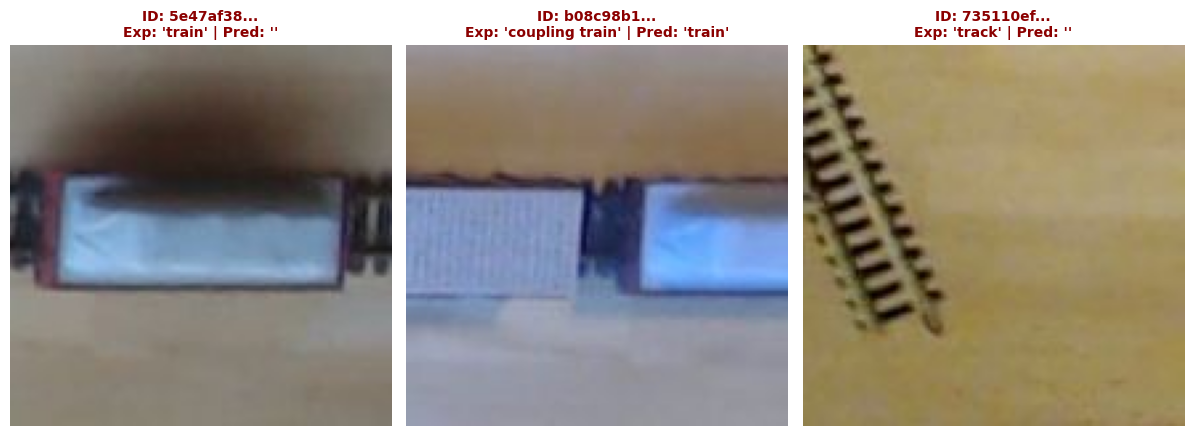

In [6]:
import requests
import matplotlib.pyplot as plt
from PIL import Image
import os

# --- Configuration ---
API_URL = "https://ui.rails49.org/api/test-cnn"
# Assuming the notebook is running in the project root or you have access to this path
DATA_DIR = "/Users/boser/iot/track-occupancy/dataset/data"
# --- Call the API ---
print(f"Calling {API_URL} ... (live classification will be suspended during test)")
try:
    response = requests.get(API_URL, timeout=300)
    response.raise_for_status()
    data = response.json()
except Exception as e:
    print(f"Error calling API: {e}")
    data = None
if data:
    # --- Report Results ---
    print("-" * 50)
    print("📊 CNN BATCH TEST RESULTS")
    print("-" * 50)
    print(f"Total Samples:      {data['total_samples']}")
    print(f"Misclassified:      {data['misclassified_count']}")
    print(f"Accuracy:           {float(data['accuracy']) * 100:.2f}%")
    print(f"Avg Inference Time: {data['avg_inference_ms']} ms")
    print("-" * 50)
    # --- Display Misclassified Samples ---
    misclassified = data.get("misclassified", [])
    if not misclassified:
        print("✅ No misclassified samples found!")
    else:
        print(f"🔍 Visualizing {len(misclassified)} misclassified samples...")

        # Calculate grid layout
        cols = 4
        rows = (len(misclassified) + cols - 1) // cols
        plt.figure(figsize=(16, 4.5 * rows))

        for i, item in enumerate(misclassified):
            img_id = item["id"]
            expected = item["expected"]
            predicted = item["predicted"]

            img_path = os.path.join(DATA_DIR, f"{img_id}.jpg")

            plt.subplot(rows, cols, i + 1)
            if os.path.exists(img_path):
                img = Image.open(img_path)
                plt.imshow(img)
                plt.title(
                    f"ID: {img_id[:8]}...\nExp: '{expected}' | Pred: '{predicted}'",
                    color="darkred",
                    fontweight="bold",
                    fontsize=10,
                )
            else:
                plt.text(
                    0.5,
                    0.5,
                    f"Image not found:\n{img_id[:8]}",
                    ha="center",
                    va="center",
                )
                plt.title(f"Exp: {expected} | Pred: {predicted}", color="red")

            plt.axis("off")

        plt.tight_layout()
        plt.show()